Found 1 TIFF(s) in 'input'
Target removed fraction: 0.50 (tolerance ±0.02)

[1/1] Mitochondria  shape=(24, 1608, 1365) dtype=uint32
  [pre3d] label=5: filled 1 hole(s), +1 px
  [pre3d] label=7: filled 1 hole(s), +1 px
  [pre3d] label=8: filled 3 hole(s), +30 px
  [pre3d] label=9: filled 1 hole(s), +2 px
  [pre3d] label=13: filled 1 hole(s), +1 px


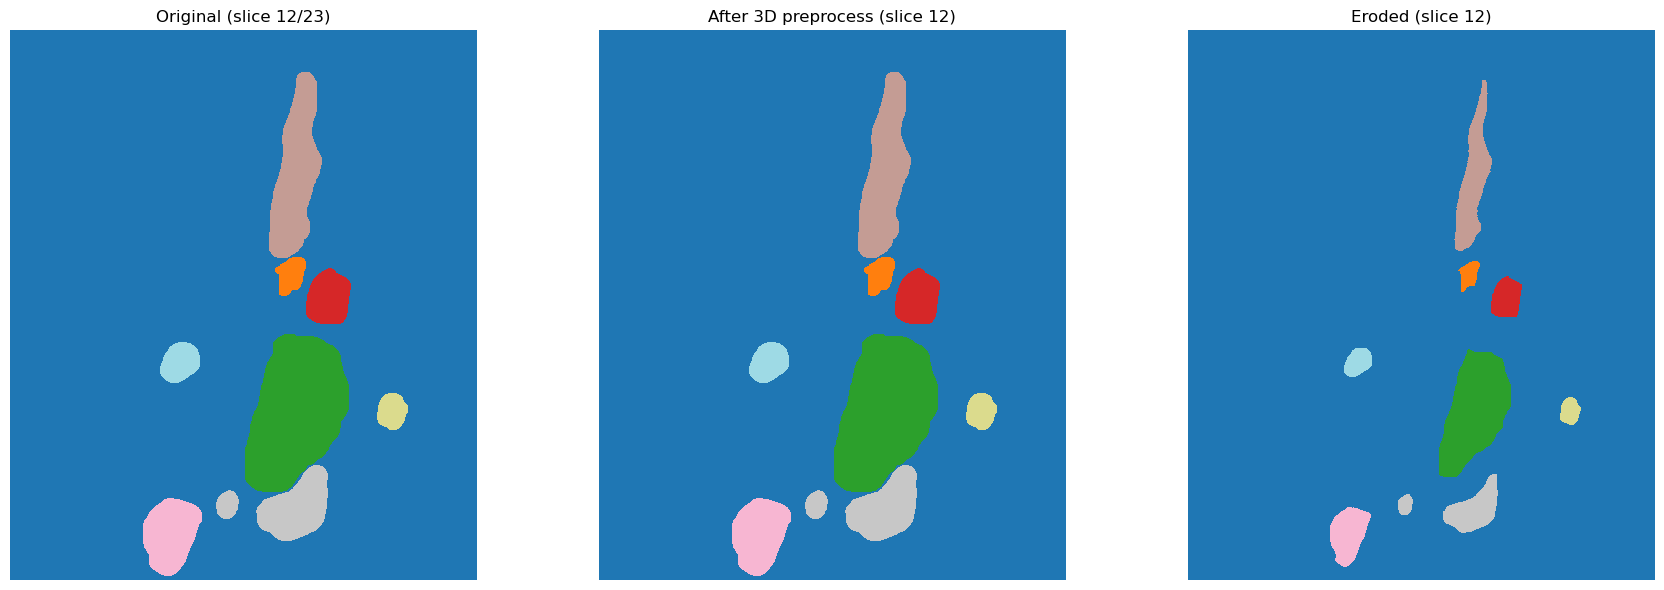

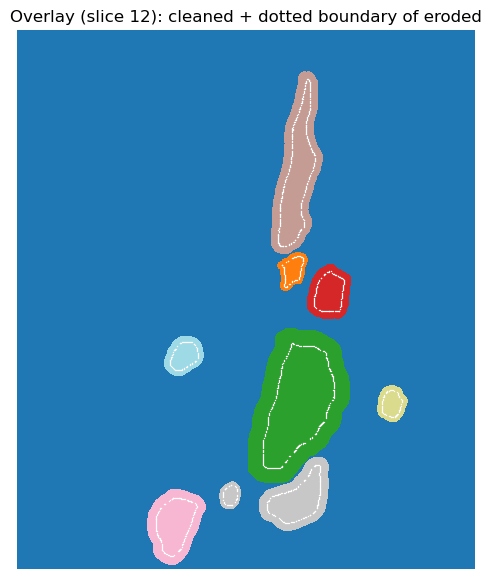

  saved: output\Mitochondria__even_eroded_rm50pct.tif
  preprocess summary: labels changed=5, hole pixels added=35, stray pixels removed=0
  stats over components: n=148, removed mean/min/max=0.500/0.500/0.500 (target 0.50±0.02)
  saved: output\Mitochondria__even_eroded_stats.csv
  saved: output\Mitochondria__preprocess_stats.csv

Done.


In [1]:
# Even edge erosion (morphological-style) until a target proportion of pixels are removed
# Default: remove 50% of pixels PER LABEL (per-slice for 3D), within ±2% tolerance.
#
# Works for:
#   - 2D (H,W)
#   - 3D (Z,H,W)
#
# Preprocessing added before erosion:
#   1) Fill holes in labels and report which label had holes filled and how many pixels were added.
#   2) Remove disconnected pixels of the same label, keeping only the larger group.
#      - For 2D: connectivity is 4-neighborhood on the slice.
#      - For 3D: connectivity is 6-neighborhood in x, y, and z across the full stack.
#
# Approach (geodesic/even-from-edge):
#   - For each label/component, compute geodesic distance-to-boundary (inside-object)
#   - Remove pixels in order of increasing distance-to-boundary (i.e., peel layers from edges inward)
#   - Choose cutoff so removed fraction ~= target within tolerance
#
# NOTE: For "even erosion", distance-to-boundary (in-object) is the right metric, not distance-to-centroid.

import os, glob, math
from collections import deque

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

# CPU geodesic distance using scikit-image MCP (exact inside-mask shortest path)
try:
    from skimage.graph import MCP_Geometric
except Exception as e:
    raise ImportError(
        "This script requires scikit-image for geodesic distance.\n"
        "Install: pip install scikit-image\n"
        f"Import error: {repr(e)}"
    )

# ----------------------------
# Settings
# ----------------------------
INPUT_DIR = "input"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

REMOVE_FRACTION = 0.5   # remove 50% of pixels (default)
TOL = 0.02              # ±2% tolerance on removed fraction
MIN_PIXELS = 1          # keep at least this many pixels per component
SAVE_STATS_CSV = True
SAVE_PREPROCESS_CSV = True

# Overlay dotted boundary of the FINAL eroded label
DOT_SPACING = 3
DOT_SIZE = 1.0

# ----------------------------
# Helpers
# ----------------------------
def boundary_mask(binmask: np.ndarray) -> np.ndarray:
    """4-neighborhood boundary mask (True on boundary pixels) for a boolean mask."""
    m = binmask
    b = np.zeros_like(m, dtype=bool)
    b[:-1, :] |= (m[:-1, :] & (m[:-1, :] != m[1:, :]))
    b[1:,  :] |= (m[1:,  :] & (m[1:,  :] != m[:-1, :]))
    b[:, :-1] |= (m[:, :-1] & (m[:, :-1] != m[:, 1:]))
    b[:, 1:]  |= (m[:, 1:]  & (m[:, 1:]  != m[:, :-1]))
    b &= m
    return b

def dotted_points_from_mask(mask: np.ndarray, spacing: int):
    ys, xs = np.where(mask)
    if ys.size == 0:
        return ys, xs
    keep = ((ys + xs) % spacing) == 0
    return ys[keep], xs[keep]

def show_labels(arr2d, title, ax=None):
    if ax is None:
        plt.figure(figsize=(6, 6))
        plt.title(title)
        plt.axis("off")
        plt.imshow(arr2d, cmap="tab20", interpolation="nearest")
        plt.show()
    else:
        ax.set_title(title)
        ax.axis("off")
        ax.imshow(arr2d, cmap="tab20", interpolation="nearest")

def show_overlay_dotted(original2d, eroded2d, title):
    b = boundary_mask(eroded2d > 0)
    ys, xs = dotted_points_from_mask(b, DOT_SPACING)
    plt.figure(figsize=(7, 7))
    plt.title(title)
    plt.axis("off")
    plt.imshow(original2d, cmap="tab20", interpolation="nearest")
    if ys.size:
        plt.scatter(xs, ys, s=DOT_SIZE, c="white", marker="o", linewidths=0)
    plt.show()

def summarize_stats(rows):
    if not rows:
        return None
    removed = np.array([r["removed_frac"] for r in rows], dtype=np.float32)
    kept = np.array([r["kept_frac"] for r in rows], dtype=np.float32)
    return {
        "n": int(len(rows)),
        "removed_mean": float(removed.mean()),
        "removed_min": float(removed.min()),
        "removed_max": float(removed.max()),
        "kept_mean": float(kept.mean()),
        "kept_min": float(kept.min()),
        "kept_max": float(kept.max()),
    }

def write_stats_csv(path, rows):
    if not rows:
        return
    cols = [
        "file", "z", "label_id", "component_id",
        "area_orig", "area_new",
        "removed_frac", "kept_frac",
        "target_removed", "tol",
        "achieved_within_tol",
        "cutoff_distance"
    ]
    with open(path, "w", newline="") as f:
        f.write(",".join(cols) + "\n")
        for r in rows:
            f.write(",".join(str(r.get(c, "")) for c in cols) + "\n")

def write_preprocess_csv(path, rows):
    if not rows:
        return
    cols = [
        "file", "z", "label_id",
        "hole_components_filled", "hole_pixels_added",
        "stray_components_removed", "stray_pixels_removed",
        "pixels_after_preprocess"
    ]
    with open(path, "w", newline="") as f:
        f.write(",".join(cols) + "\n")
        for r in rows:
            f.write(",".join(str(r.get(c, "")) for c in cols) + "\n")

# --- Connected components (2D 4-neighborhood / 3D 6-neighborhood) ---
def connected_components_4(mask: np.ndarray):
    """Return list of 2D components, each as array of (y,x) pixels, 4-connectivity."""
    H, W = mask.shape
    visited = np.zeros_like(mask, dtype=bool)
    comps = []
    nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    ys_all, xs_all = np.where(mask)
    for y0, x0 in zip(ys_all, xs_all):
        if visited[y0, x0] or (not mask[y0, x0]):
            continue
        q = [(y0, x0)]
        visited[y0, x0] = True
        comp = [(y0, x0)]
        while q:
            y, x = q.pop()
            for dy, dx in nbrs:
                yy, xx = y + dy, x + dx
                if 0 <= yy < H and 0 <= xx < W and (not visited[yy, xx]) and mask[yy, xx]:
                    visited[yy, xx] = True
                    q.append((yy, xx))
                    comp.append((yy, xx))
        comps.append(np.array(comp, dtype=np.int32))
    return comps

def connected_components_6(mask3d: np.ndarray):
    """Return list of 3D components, each as array of (z,y,x) voxels, 6-connectivity."""
    Z, H, W = mask3d.shape
    visited = np.zeros_like(mask3d, dtype=bool)
    comps = []
    nbrs = [
        (-1, 0, 0), (1, 0, 0),
        (0, -1, 0), (0, 1, 0),
        (0, 0, -1), (0, 0, 1),
    ]

    zs_all, ys_all, xs_all = np.where(mask3d)
    for z0, y0, x0 in zip(zs_all, ys_all, xs_all):
        if visited[z0, y0, x0] or (not mask3d[z0, y0, x0]):
            continue
        q = deque([(z0, y0, x0)])
        visited[z0, y0, x0] = True
        comp = [(z0, y0, x0)]
        while q:
            z, y, x = q.popleft()
            for dz, dy, dx in nbrs:
                zz, yy, xx = z + dz, y + dy, x + dx
                if (
                    0 <= zz < Z and 0 <= yy < H and 0 <= xx < W
                    and (not visited[zz, yy, xx])
                    and mask3d[zz, yy, xx]
                ):
                    visited[zz, yy, xx] = True
                    q.append((zz, yy, xx))
                    comp.append((zz, yy, xx))
        comps.append(np.array(comp, dtype=np.int32))
    return comps

def fill_holes_in_mask(mask: np.ndarray):
    """
    Fill holes in a 2D binary mask using 4-connectivity.
    Returns:
        filled_mask, hole_component_count, hole_pixel_count
    """
    if not np.any(mask):
        return mask.copy(), 0, 0

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1

    sub = mask[y0:y1, x0:x1]
    bg = ~sub
    H, W = bg.shape
    visited = np.zeros_like(bg, dtype=bool)
    q = deque()

    def push(y, x):
        if 0 <= y < H and 0 <= x < W and bg[y, x] and (not visited[y, x]):
            visited[y, x] = True
            q.append((y, x))

    for x in range(W):
        push(0, x)
        push(H - 1, x)
    for y in range(H):
        push(y, 0)
        push(y, W - 1)

    while q:
        y, x = q.popleft()
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            push(y + dy, x + dx)

    holes = bg & (~visited)
    hole_pixel_count = int(holes.sum())

    if hole_pixel_count == 0:
        return mask.copy(), 0, 0

    hole_components = connected_components_4(holes)
    filled_sub = sub | holes

    filled = mask.copy()
    filled[y0:y1, x0:x1] = filled_sub
    return filled, len(hole_components), hole_pixel_count

def preprocess_slice_labels(lbl2d: np.ndarray, file_name: str, z: int):
    """
    2D preprocessing:
      1) Fill holes inside each label.
      2) Keep only the largest connected component for each label.
    Returns cleaned labels and preprocessing report rows.
    """
    if not np.issubdtype(lbl2d.dtype, np.integer):
        lbl2d = lbl2d.astype(np.int32)

    out = np.zeros_like(lbl2d)
    rows = []

    ids = np.unique(lbl2d)
    ids = ids[ids != 0]

    for lab in ids:
        mask = (lbl2d == lab)
        if not np.any(mask):
            continue

        # 1) Fill holes
        filled_mask, hole_comp_count, hole_pixel_count = fill_holes_in_mask(mask)

        # 2) Keep only the largest connected component
        comps = connected_components_4(filled_mask)
        if len(comps) == 0:
            continue

        comp_sizes = [c.shape[0] for c in comps]
        keep_idx = int(np.argmax(comp_sizes))
        keep_comp = comps[keep_idx]

        stray_pixels_removed = int(sum(comp_sizes) - comp_sizes[keep_idx])
        stray_components_removed = int(len(comps) - 1)

        out[keep_comp[:, 0], keep_comp[:, 1]] = lab

        if hole_pixel_count > 0 or stray_pixels_removed > 0:
            print(
                f"  [pre2d] z={z} label={int(lab)}:"
                + (
                    f" filled {hole_comp_count} hole(s), +{hole_pixel_count} px;"
                    if hole_pixel_count > 0 else ""
                )
                + (
                    f" removed {stray_pixels_removed} stray px in {stray_components_removed} extra component(s)"
                    if stray_pixels_removed > 0 else ""
                )
            )

            rows.append({
                "file": file_name,
                "z": int(z),
                "label_id": int(lab),
                "hole_components_filled": int(hole_comp_count),
                "hole_pixels_added": int(hole_pixel_count),
                "stray_components_removed": int(stray_components_removed),
                "stray_pixels_removed": int(stray_pixels_removed),
                "pixels_after_preprocess": int(keep_comp.shape[0]),
            })
        else:
            out[keep_comp[:, 0], keep_comp[:, 1]] = lab

    return out, rows

def preprocess_volume_labels(lbl3d: np.ndarray, file_name: str):
    """
    3D preprocessing:
      1) Fill holes per slice inside each label.
      2) Remove disconnected same-label groups using 3D connectivity (6-neighborhood).
         Keep only the largest 3D component for each label.
    Returns cleaned labels and preprocessing report rows.
    """
    if not np.issubdtype(lbl3d.dtype, np.integer):
        lbl3d = lbl3d.astype(np.int32)

    out = np.zeros_like(lbl3d)
    rows = []

    ids = np.unique(lbl3d)
    ids = ids[ids != 0]

    for lab in ids:
        mask = (lbl3d == lab)
        if not np.any(mask):
            continue

        # Fill holes per slice
        filled = np.zeros_like(mask, dtype=bool)
        hole_components_filled = 0
        hole_pixels_added = 0

        for z in range(mask.shape[0]):
            filled[z], hc, hp = fill_holes_in_mask(mask[z])
            hole_components_filled += hc
            hole_pixels_added += hp

        # Remove disconnected 3D same-label groups
        comps = connected_components_6(filled)
        if len(comps) == 0:
            continue

        comp_sizes = [c.shape[0] for c in comps]
        keep_idx = int(np.argmax(comp_sizes))
        keep_comp = comps[keep_idx]

        stray_pixels_removed = int(sum(comp_sizes) - comp_sizes[keep_idx])
        stray_components_removed = int(len(comps) - 1)

        out[keep_comp[:, 0], keep_comp[:, 1], keep_comp[:, 2]] = lab

        if hole_pixels_added > 0 or stray_pixels_removed > 0:
            parts = []
            if hole_pixels_added > 0:
                parts.append(f"filled {hole_components_filled} hole(s), +{hole_pixels_added} px")
            if stray_pixels_removed > 0:
                parts.append(
                    f"removed {stray_pixels_removed} stray px in {stray_components_removed} extra 3D component(s)"
                )
            print(f"  [pre3d] label={int(lab)}: " + "; ".join(parts))

            rows.append({
                "file": file_name,
                "z": "all",
                "label_id": int(lab),
                "hole_components_filled": int(hole_components_filled),
                "hole_pixels_added": int(hole_pixels_added),
                "stray_components_removed": int(stray_components_removed),
                "stray_pixels_removed": int(stray_pixels_removed),
                "pixels_after_preprocess": int(keep_comp.shape[0]),
            })
        else:
            out[keep_comp[:, 0], keep_comp[:, 1], keep_comp[:, 2]] = lab

    return out, rows

# --- Geodesic distance-to-boundary inside a component ---
def geodesic_distance_to_boundary(comp_mask: np.ndarray) -> np.ndarray:
    """
    comp_mask: boolean (H,W) mask of a single connected component
    returns dist array (H,W) with inf outside mask, 0 at boundary, increasing inward
    """
    INF = np.inf
    costs = np.where(comp_mask, 1.0, INF).astype(np.float32)

    bmask = boundary_mask(comp_mask)
    seeds = list(zip(*np.where(bmask)))
    if len(seeds) == 0:
        seeds = list(zip(*np.where(comp_mask)))

    mcp = MCP_Geometric(costs)
    dist, _ = mcp.find_costs(seeds)
    return dist

def erode_component_even(comp_pixels: np.ndarray, comp_mask: np.ndarray,
                         remove_fraction: float, tol: float, min_pixels: int):
    """
    Erode evenly from edges inward until removed fraction ~= target within tol.
    Returns keep_pixels (Nyx2), achieved_removed_frac, cutoff_distance
    """
    ys = comp_pixels[:, 0]
    xs = comp_pixels[:, 1]
    n = ys.size
    if n == 0:
        return comp_pixels, 0.0, 0.0

    target_kept = 1.0 - remove_fraction

    k_target = int(round(target_kept * n))
    k_min = int(math.ceil((target_kept - tol) * n))
    k_max = int(math.floor((target_kept + tol) * n))
    k_min = max(min_pixels, min(k_min, n))
    k_max = max(min_pixels, min(k_max, n))
    k_target = max(min_pixels, min(k_target, n))

    dist = geodesic_distance_to_boundary(comp_mask)
    d = dist[ys, xs].astype(np.float32)

    # keep pixels with largest distance-to-boundary
    order = np.argsort(d)[::-1]

    # Choose k that hits tolerance: clamp target within [k_min, k_max]
    k = int(np.clip(k_target, k_min, k_max))

    keep_idx = order[:k]
    keep_pixels = comp_pixels[keep_idx]

    removed_frac = 1.0 - (k / n)
    cutoff_distance = float(d[order[k - 1]]) if k > 0 else 0.0
    return keep_pixels, float(removed_frac), cutoff_distance

def erode_slice_even(lbl2d: np.ndarray, remove_fraction: float, tol: float,
                     min_pixels: int, file_name: str, z: int):
    """
    lbl2d: (H,W) integer labels
    returns out2d and per-component stats rows
    """
    if not np.issubdtype(lbl2d.dtype, np.integer):
        lbl2d = lbl2d.astype(np.int32)

    out = np.zeros_like(lbl2d)
    rows = []

    ids = np.unique(lbl2d)
    ids = ids[ids != 0]

    for lab in ids:
        mask = (lbl2d == lab)
        comps = connected_components_4(mask)

        for ci, comp in enumerate(comps):
            comp_mask = np.zeros_like(mask, dtype=bool)
            comp_mask[comp[:, 0], comp[:, 1]] = True

            keep_pixels, removed_frac, cutoff = erode_component_even(
                comp, comp_mask, remove_fraction, tol, min_pixels
            )

            out[keep_pixels[:, 0], keep_pixels[:, 1]] = lab

            n0 = comp.shape[0]
            n1 = keep_pixels.shape[0]
            kept_frac = n1 / max(n0, 1)
            within = (abs(removed_frac - remove_fraction) <= tol) or (n0 <= min_pixels)

            rows.append({
                "file": file_name,
                "z": z,
                "label_id": int(lab),
                "component_id": int(ci),
                "area_orig": int(n0),
                "area_new": int(n1),
                "removed_frac": float(removed_frac),
                "kept_frac": float(kept_frac),
                "target_removed": float(remove_fraction),
                "tol": float(tol),
                "achieved_within_tol": bool(within),
                "cutoff_distance": float(cutoff),
            })

    return out, rows

# ----------------------------
# Batch processing
# ----------------------------
tif_files = sorted(glob.glob(os.path.join(INPUT_DIR, "*.tif")) + glob.glob(os.path.join(INPUT_DIR, "*.tiff")))
if not tif_files:
    raise FileNotFoundError(f"No TIFFs found in '{INPUT_DIR}'")

print(f"Found {len(tif_files)} TIFF(s) in '{INPUT_DIR}'")
print(f"Target removed fraction: {REMOVE_FRACTION:.2f} (tolerance ±{TOL:.2f})")

for i, in_path in enumerate(tif_files, start=1):
    name = os.path.splitext(os.path.basename(in_path))[0]
    out_path = os.path.join(OUTPUT_DIR, f"{name}__even_eroded_rm{int(REMOVE_FRACTION*100)}pct.tif")
    csv_path = os.path.join(OUTPUT_DIR, f"{name}__even_eroded_stats.csv")
    pre_csv_path = os.path.join(OUTPUT_DIR, f"{name}__preprocess_stats.csv")

    lbl = np.asarray(tiff.imread(in_path))
    print(f"\n[{i}/{len(tif_files)}] {name}  shape={lbl.shape} dtype={lbl.dtype}")

    all_rows = []
    pre_rows = []

    if lbl.ndim == 2:
        # Preprocess first
        cleaned2d, pre = preprocess_slice_labels(lbl, name, z=0)
        pre_rows.extend(pre)

        # Erode cleaned labels
        out2d, rows = erode_slice_even(cleaned2d, REMOVE_FRACTION, TOL, MIN_PIXELS, name, z=0)
        all_rows.extend(rows)

        # Display
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        show_labels(lbl, "Original labels (2D)", ax=axs[0])
        show_labels(cleaned2d, "After hole fill + keep largest component", ax=axs[1])
        show_labels(out2d, f"Even edge erosion (remove {int(REMOVE_FRACTION*100)}% ±{int(TOL*100)}%)", ax=axs[2])
        plt.tight_layout()
        plt.show()

        show_overlay_dotted(cleaned2d, out2d, "Overlay: cleaned labels + dotted boundary of eroded")

        # Save
        tiff.imwrite(out_path, out2d, photometric="minisblack")
        print("  saved:", out_path)

    elif lbl.ndim == 3:
        Z, H, W = lbl.shape

        # 3D preprocessing first
        cleaned3d, pre = preprocess_volume_labels(lbl, name)
        pre_rows.extend(pre)

        out3d = np.zeros_like(lbl)
        for z in range(Z):
            out3d[z], rows = erode_slice_even(cleaned3d[z], REMOVE_FRACTION, TOL, MIN_PIXELS, name, z=z)
            all_rows.extend(rows)

        # Display middle slice
        z0 = Z // 2
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        show_labels(lbl[z0], f"Original (slice {z0}/{Z-1})", ax=axs[0])
        show_labels(cleaned3d[z0], f"After 3D preprocess (slice {z0})", ax=axs[1])
        show_labels(out3d[z0], f"Eroded (slice {z0})", ax=axs[2])
        plt.tight_layout()
        plt.show()

        show_overlay_dotted(cleaned3d[z0], out3d[z0], f"Overlay (slice {z0}): cleaned + dotted boundary of eroded")

        # Save
        tiff.imwrite(out_path, out3d, photometric="minisblack")
        print("  saved:", out_path)

    else:
        print("  [SKIP] Only 2D (H,W) or 3D (Z,H,W) supported.")
        continue

    # Preprocess stats
    if pre_rows:
        total_hole_px = sum(int(r["hole_pixels_added"]) for r in pre_rows)
        total_stray_px = sum(int(r["stray_pixels_removed"]) for r in pre_rows)
        print(
            f"  preprocess summary: labels changed={len(pre_rows)}, "
            f"hole pixels added={total_hole_px}, stray pixels removed={total_stray_px}"
        )

    # Erosion stats
    summ = summarize_stats(all_rows)
    if summ:
        print(
            f"  stats over components: n={summ['n']}, "
            f"removed mean/min/max={summ['removed_mean']:.3f}/{summ['removed_min']:.3f}/{summ['removed_max']:.3f} "
            f"(target {REMOVE_FRACTION:.2f}±{TOL:.2f})"
        )

    if SAVE_STATS_CSV and all_rows:
        write_stats_csv(csv_path, all_rows)
        print("  saved:", csv_path)

    if SAVE_PREPROCESS_CSV and pre_rows:
        write_preprocess_csv(pre_csv_path, pre_rows)
        print("  saved:", pre_csv_path)

print("\nDone.")